In [1]:
# pip install sqlalchemy psycopg2-binary

# Loading sql tables to pandas dataframes

In this part, we are going to load the tables already created by using the sql files in the `sql`folder of this project. To do that, we are using `sqlalchemy` library in python in order to read SQL queries and `extract.py` file where the connection of the database is done. Remember to modify the credentials in the `config.yaml` to setup your login access.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import seaborn as sns; sns.set()
from sqlalchemy import create_engine
import extract
import plotting_functions

engine = extract.get_engine()

raw_data = extract.extract_table("loan_approval_prediction_raw")
customers = extract.extract_table("staging_customers")
financials = extract.extract_table("staging_financials")
loans = extract.extract_table("staging_loans")

# engine.close()

# Exploring the datasets and making the feature engineering

## Customers dataset

To beging with, let's print a general information of the `customers` dataframe (the firts rows of the dataframe) together with the info() command to detect null information.

In [3]:
customers.head()

,customer_id,loan_id,gender,married,education,dependents
0,1,LP001002,Male,No,Graduate,0.0
1,2,LP001003,Male,Yes,Graduate,1.0
2,3,LP001005,Male,Yes,Graduate,0.0
3,4,LP001006,Male,Yes,Not Graduate,0.0
4,5,LP001008,Male,No,Graduate,0.0


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  598 non-null    int64  
 1   loan_id      598 non-null    object 
 2   gender       598 non-null    object 
 3   married      598 non-null    object 
 4   education    598 non-null    object 
 5   dependents   586 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 28.2+ KB


As it can be seen from above, the `customers` dataframe contains 6 columns in total, which includes the following information:

* `customer_id`: It is an identification number for each customer.
* `loan_id`: It is an identification serial for each loan of each customer.
* `gender`: If the customer is male or female.
* `married`: If the customer is married or not.
* `education`: If the customer has an graduation degree or not.
* `dependents`: How many dependents each customer has.

The dataset has 598 rows, from which only the *dependents* row contains null values. Let's explore which customers do not have dependents information:

In [5]:
# Find the list of customers with no information regarding their dependents 
customers[customers["dependents"].isnull()]

,customer_id,loan_id,gender,married,education,dependents
101,102,LP001350,Male,Yes,Graduate,NaN
118,119,LP001426,Male,Yes,Graduate,NaN
221,222,LP001754,Male,Yes,Not Graduate,NaN
287,288,LP001945,Female,No,Graduate,NaN
295,296,LP001972,Male,Yes,Not Graduate,NaN
325,326,LP002100,Male,No,Graduate,NaN
327,328,LP002106,Male,Yes,Graduate,NaN
338,339,LP002130,Male,Yes,Not Graduate,NaN
347,348,LP002144,Female,No,Graduate,NaN
504,505,LP002682,Male,Yes,Not Graduate,NaN


Let's also find if the `customers` dataframe contains repeated customers or loan ids. To do that, we can use the method `duplicated()` that allows us to check for all the values in a group of columns if some of them are repeated:

In [6]:
# Finding rows with the same customer_id value
customers[customers.duplicated(subset=['customer_id'], keep=False) == True]

,customer_id,loan_id,gender,married,education,dependents


In [7]:
# Finding rows with the same loan_id value
customers[customers.duplicated(subset=['loan_id'], keep=False) == True]

,customer_id,loan_id,gender,married,education,dependents


As it can be seen, each row has unique **customer_id** and **loan_id**. We can also estimate the percentage of male and female customers in the dataset and get also the percentage of educated and married customers (in general or grouped by gender).

In [8]:
customers.shape

(598, 6)

In [9]:
# Computing the percentages of male and female customers in the dataset
gender_customers = customers[["gender", "customer_id"]].groupby("gender").count()

perc_male_customers = 100.0*gender_customers.loc["Male", "customer_id"] / customers.shape[0]
perc_female_customers = 100.0*gender_customers.loc["Female", "customer_id"] / customers.shape[0]

print(f"The percentage of male customers is {perc_male_customers:.2f}% while female customers percentage is {perc_female_customers:.2f}%.")

The percentage of male customers is 81.44% while female customers percentage is 18.56%.


In [10]:
# Computing the percentage of educated customers grouped by gender only
educated_customers = customers[["gender", "education", "customer_id"]].groupby(["gender", "education"]).count()

perc_edu_female = educated_customers.loc[("Female", "Graduate"), "customer_id"] / customers[customers["gender"]=="Female"].shape[0]
perc_edu_male = educated_customers.loc[("Male", "Graduate"), "customer_id"] / customers[customers["gender"]=="Male"].shape[0]

print(f"Percentage of graduated female customers is {100.0*perc_edu_female:.2f}% while the one for graduated male customers is {100.0*perc_edu_male:.2f}%.")

print(educated_customers)

Percentage of graduated female customers is 81.98% while the one for graduated male customers is 76.80%.
                     customer_id
gender education                
Female Graduate               91
       Not Graduate           20
Male   Graduate              374
       Not Graduate          113


In [11]:
# Computing the percentage of married customers grouped by gender only
married_customers = customers[["gender", "married", "customer_id"]].groupby(["gender", "married"]).count()

perc_married_female = married_customers.loc[("Female", "Yes"), "customer_id"] / customers[customers["gender"]=="Female"].shape[0]
perc_married_male = married_customers.loc[("Male", "Yes"), "customer_id"] / customers[customers["gender"]=="Male"].shape[0]

print(f"The percentage of married female customers is {100.0*perc_married_female:.2f}% while the one for married male customers is {100.0*perc_married_male:.2f}%.")
print(married_customers)

The percentage of married female customers is 27.93% while the one for married male customers is 73.31%.
                customer_id
gender married             
Female No                80
       Yes               31
Male   No               130
       Yes              357


As seen up to now, the graduation rate seems to be similar for female and male customers (81.98% and 76.80% respectively), while the married rate shows a huge contrast (27.93% for female customers in comparison with 73.31% for male customers). It is also possible to study how marriage and education categories are defined by gender, as it is done as follows:

In [12]:
# Counting customers by grouping them into gender, married and education status
educated_married_customers = customers[["gender", "married", "education", "customer_id"]]. groupby(["gender", "married", "education"]).count()
total_female_customers = customers[customers["gender"]=="Female"].shape[0]

perc_married_graduated_female = educated_married_customers.loc[("Female", "Yes", "Graduate"), "customer_id"] / total_female_customers
perc_married_not_graduated_female = educated_married_customers.loc[("Female", "Yes", "Not Graduate"), "customer_id"] / total_female_customers
perc_graduate_non_married_female = educated_married_customers.loc[("Female", "No", "Graduate"), "customer_id"] / total_female_customers
perc_neither_married_nor_graduate_female = educated_married_customers.loc[("Female", "No", "Not Graduate"), "customer_id"] / total_female_customers

print(educated_married_customers)

print(f"The percentage of female customers that are married and graduate is {100.0*perc_married_graduated_female:.2f}%.")
print(f"The percentage of female customers that are married but not graduate is {100.0*perc_married_not_graduated_female:.2f}%.")
print(f"The percentage of female customers that are graduate but not married is {100.0*perc_graduate_non_married_female:.2f}%.")
print(f"The percentage of female customers that are neither married nor graduate is {100.0*perc_neither_married_nor_graduate_female:.2f}%.")
print(f"Total number of female customers considered is {total_female_customers}.")

                             customer_id
gender married education                
Female No      Graduate               66
               Not Graduate           14
       Yes     Graduate               25
               Not Graduate            6
Male   No      Graduate               99
               Not Graduate           31
       Yes     Graduate              275
               Not Graduate           82
The percentage of female customers that are married and graduate is 22.52%.
The percentage of female customers that are married but not graduate is 5.41%.
The percentage of female customers that are graduate but not married is 59.46%.
The percentage of female customers that are neither married nor graduate is 12.61%.
Total number of female customers considered is 111.


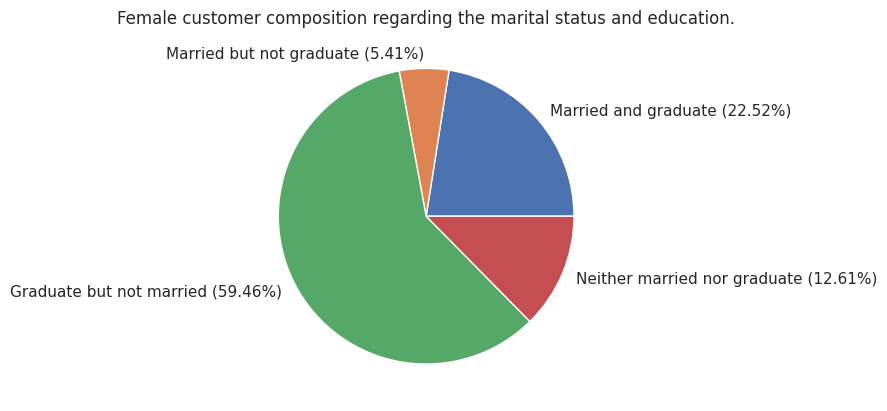

In [13]:
# Data for the pie chart

sizes = np.array([perc_married_graduated_female, 
                  perc_married_not_graduated_female, 
                  perc_graduate_non_married_female, 
                  perc_neither_married_nor_graduate_female])

labels = [f"Married and graduate ({100.0*perc_married_graduated_female:.2f}%)", 
          f"Married but not graduate ({100.0*perc_married_not_graduated_female:.2f}%)",
          f"Graduate but not married ({100.0*perc_graduate_non_married_female:.2f}%)",
          f"Neither married nor graduate ({100.0*perc_neither_married_nor_graduate_female:.2f}%)"]

title = "Female customer composition regarding the marital status and education."

plotting_functions.plotting_pie_chats_distributions(sizes, labels, title)

In [14]:
total_male_customers = customers[customers["gender"]=="Male"].shape[0]

perc_married_graduated_male = educated_married_customers.loc[("Male", "Yes", "Graduate"), "customer_id"] / total_male_customers
perc_married_not_graduated_male = educated_married_customers.loc[("Male", "Yes", "Not Graduate"), "customer_id"] / total_male_customers
perc_graduate_non_married_male = educated_married_customers.loc[("Male", "No", "Graduate"), "customer_id"] / total_male_customers
perc_neither_married_nor_graduate_male = educated_married_customers.loc[("Male", "No", "Not Graduate"), "customer_id"] / total_male_customers

print(educated_married_customers)

print(f"The percentage of male customers that are married and graduate is {100.0*perc_married_graduated_male:.2f}%.")
print(f"The percentage of male customers that are married but not graduate is {100.0*perc_married_not_graduated_male:.2f}%.")
print(f"The percentage of male customers that are graduate but not married is {100.0*perc_graduate_non_married_male:.2f}%.")
print(f"The percentage of male customers that are neither married nor graduate is {100.0*perc_neither_married_nor_graduate_male:.2f}%.")
print(f"Total number of male customers considered is {total_male_customers}.")

                             customer_id
gender married education                
Female No      Graduate               66
               Not Graduate           14
       Yes     Graduate               25
               Not Graduate            6
Male   No      Graduate               99
               Not Graduate           31
       Yes     Graduate              275
               Not Graduate           82
The percentage of male customers that are married and graduate is 56.47%.
The percentage of male customers that are married but not graduate is 16.84%.
The percentage of male customers that are graduate but not married is 20.33%.
The percentage of male customers that are neither married nor graduate is 6.37%.
Total number of male customers considered is 487.


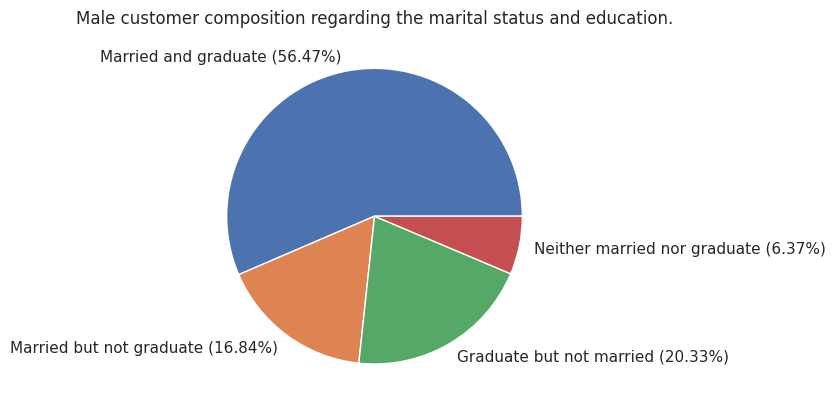

In [15]:
# Data for the pie chart

sizes = np.array([perc_married_graduated_male, 
                  perc_married_not_graduated_male, 
                  perc_graduate_non_married_male, 
                  perc_neither_married_nor_graduate_male])
labels = [f"Married and graduate ({100.0*perc_married_graduated_male:.2f}%)", 
          f"Married but not graduate ({100.0*perc_married_not_graduated_male:.2f}%)",
          f"Graduate but not married ({100.0*perc_graduate_non_married_male:.2f}%)",
          f"Neither married nor graduate ({100.0*perc_neither_married_nor_graduate_male:.2f}%)"]

title = "Male customer composition regarding the marital status and education."

plotting_functions.plotting_pie_chats_distributions(sizes, labels, title)

Then, the `pie charts` show that the female customers tends to be graduate but not married (59.46% of total female customers) while the male customers tends to be both married and graduate (56.47% of total male customers). Finally, a study of the number of dependents can be done, including a general statistical overview:

In [16]:
# Printing the statistical summary for only female customers regarding their number of dependents
customers[customers["gender"]=="Female"]["dependents"].describe()

count    109.000000
mean       0.385321
std        0.731668
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: dependents, dtype: float64

The result above is giving us some statistical information for the variable `dependents` filtering by **female customers**. This information can be summarized by the number of non-null entries (i.e number of female customers who has provided information of their dependents - 109 female customers), the mean of the distribution (0.385 dependents in average for female customers), the minimum number of dependents (0 dependents), the maximum number of dependents (3 dependents), the interquantile ranges (25%, 50% and 75% of the dependents distributions) and the standard deviation of the distribution. A good statistical parameters are the **mean** and the interquantiles ranges (IQR), specially the 50% IQR, which corresponds to the **median** of the distribution (the value for which half of the data is distributed to the left and the other half is to the right). 

The comparison between the mean and the median of a distribution can tell us how shifted is the distribution of the mean. Thus, if the median is lower than the mean, we should expect a right-skewed distribution (a higher concentration of data in the left side, where most of the data is lower than the mean) while having a median higher than the mean represents a left-skewed distribution (a higher concentration of data in the right side, higher than the mean). In this case, the distribution of the number of dependents for female customers has a mean of 0.358 while its median is 0, so we should expect a right-skewed distribution (as we will see when plotting this using a histogram in the following codelines).

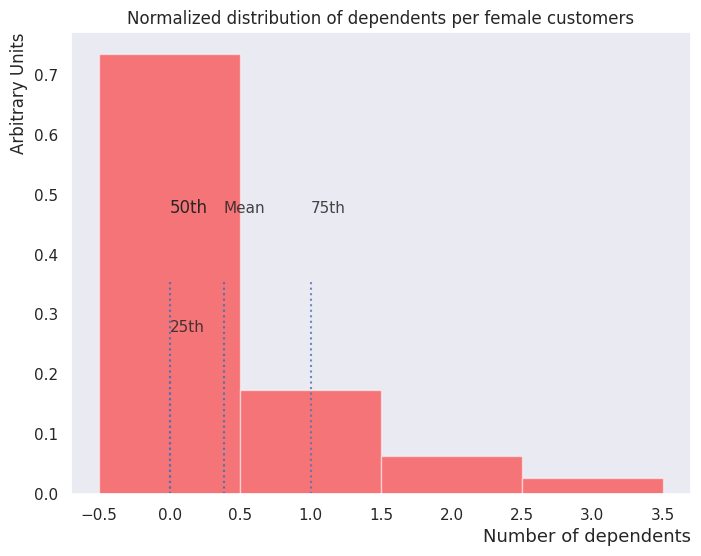

In [17]:
# Filtering the female customers's dependents in a pd.series
dependents_per_female_customers_array = customers[customers["gender"]=="Female"]["dependents"]

# Creating features dict for plotting
features_dependents_per_female = {
    "title_plot": "Normalized distribution of dependents per female customers",
    "x_title": "Number of dependents",
    "y_title": "Arbitrary Units",
    "bar_color": "red"
}

# Plotting female customers's dependents normalized distribution with some statistical values
plotting_functions.plotting_normalized_distribution_histogram(dependents_per_female_customers_array, features_dependents_per_female)

From the figure above, where the normalized number of dependents distribution for female customers is plotted, it can be seen the right-skewed distribution we were talking about earlier. In this figure, we can see that the median (50th percentile) is lower than the mean, which means that there is a higher concentration of data to the left of the mean. A similar procedure can be done for the number of dependents filtering by male customers as follows:

In [18]:
# Printing the statistical summary for only male customers regarding their number of dependents
customers[customers["gender"]=="Male"]["dependents"].describe()

count    477.000000
mean       0.840671
std        1.043075
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max        3.000000
Name: dependents, dtype: float64

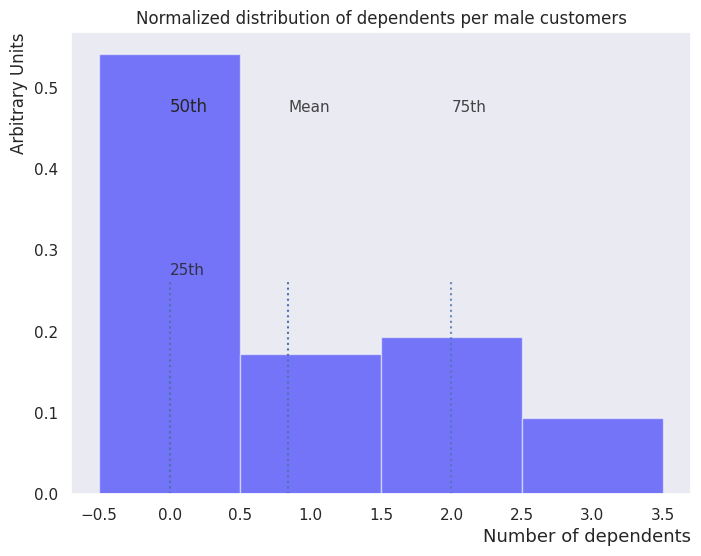

In [19]:
# Filtering the female customers's dependents in a pd.series
dependents_per_male_customers_array = customers[customers["gender"]=="Male"]["dependents"]

# Creating features dict for plotting
features_dependents_per_male = {
    "title_plot": "Normalized distribution of dependents per male customers",
    "x_title": "Number of dependents",
    "y_title": "Arbitrary Units",
    "bar_color": "blue"
}

# Plotting female customers's dependents normalized distribution with some statistical values
plotting_functions.plotting_normalized_distribution_histogram(dependents_per_male_customers_array, features_dependents_per_male)

Thus, for male customers we have 477 non-null entries (i.e more information for male than female customers) but we also observed that the median is lower than the mean (0 and 0.841 respectively), which means the dependents distribution is also right-skewed (a higher concentration of data in the left side of the distribution). This can be also observed in the figure of the normalized number of dependents distribution for male customers above.

Similar conclusions can be reached without filtering by gender, since both previous distributions (number of dependents filtered by male or female customers) obtained a similar behaviour, as it is shown the the following two codelines.

In [20]:
# Printing the statistical summary the number of dependents (without filtering by gender)
customers["dependents"].describe()

count    586.000000
mean       0.755973
std        1.007751
min        0.000000
25%        0.000000
50%        0.000000
75%        1.750000
max        3.000000
Name: dependents, dtype: float64

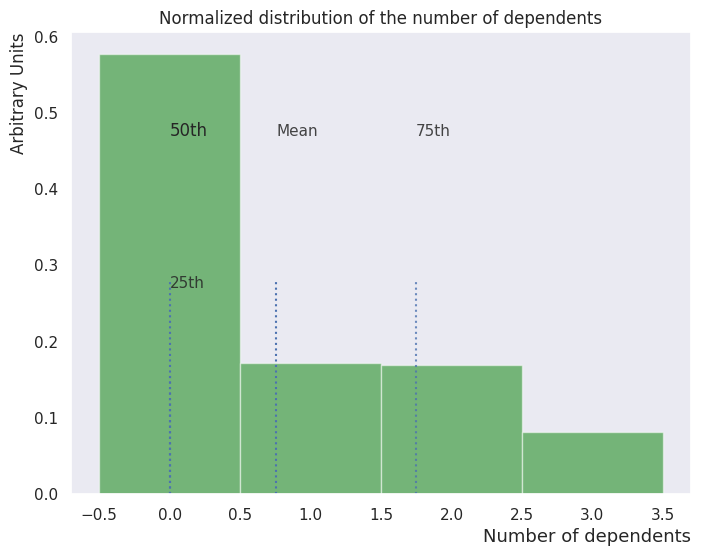

In [21]:
# Filtering the dependents distribution array in a pd.series
dependents_distribution_array = customers["dependents"]

# Creating features dict for plotting
features_dependents_distribution = {
    "title_plot": "Normalized distribution of the number of dependents",
    "x_title": "Number of dependents",
    "y_title": "Arbitrary Units",
    "bar_color": "green"
}

# Plotting female customers's dependents normalized distribution with some statistical values
plotting_functions.plotting_normalized_distribution_histogram(dependents_distribution_array, features_dependents_distribution)

We can also determine the mode of each distribution by seeing them in a histogram and taking the value that is repeated the most. A simpler way is to use the method `value_counts()`, which counts the number of repeated values in a **pd.Series**, providing at the same time the value that has a higher frequency (in this case it is 0 dependents, with 338 customers without dependents).

In [22]:
customers["dependents"].value_counts()

dependents
0.0    338
1.0    101
2.0     99
3.0     48
Name: count, dtype: int64

Finally, we can also have a plot that allow us to compare male and female number of dependents directly. To do that, we will use a `bar_plot` using `seaborn` library. The input of the barplot will be a dataframe that contains the number of dependents and the gender as main columns, together with the counts of customers in each category. To do that, we can group the *customers* dataframe by the number of dependents and use the method `value_counts()` to count the number of customers (we keep the gender column as well in the final dataframe).

In [23]:
# Grouping the customers df by number of dependents and gender.
tidy_dependents = customers[["gender", "dependents"]].groupby("dependents", as_index=False).value_counts()
tidy_dependents

,dependents,gender,count
0,0.0,Male,258
1,0.0,Female,80
2,1.0,Male,82
3,1.0,Female,19
4,2.0,Male,92
5,2.0,Female,7
6,3.0,Male,45
7,3.0,Female,3


Now, we have a tidy dataframe with the needed information. The next step is to plot the number of customers (male of female) according to their dependents number. This is done as follows:

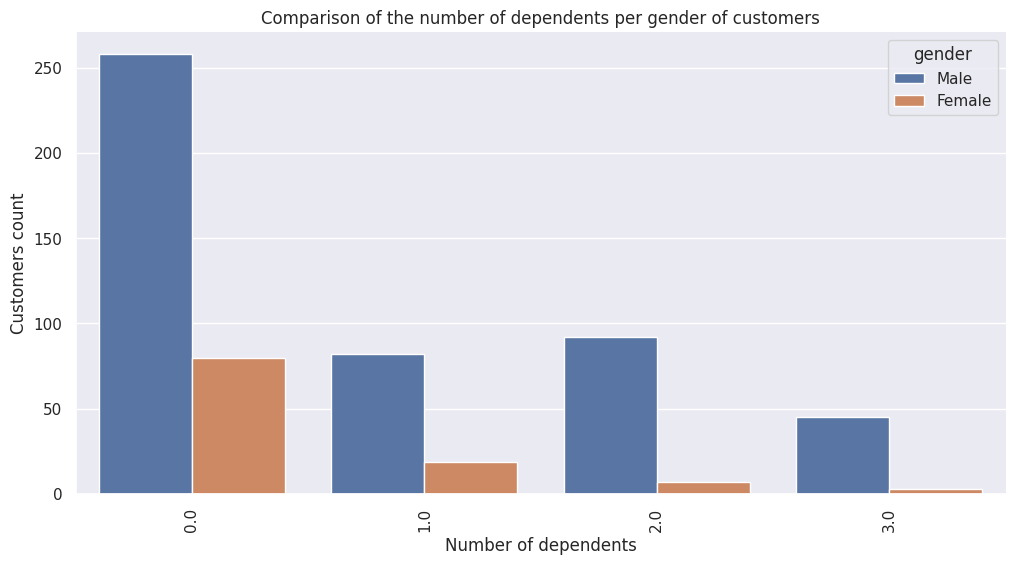

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.tick_params(axis='x', labelrotation=90)
ax1.set_xlabel('Number of dependents')
ax1.set_ylabel('Customers count')
ax1.set_title("Comparison of the number of dependents per gender of customers")

# Use the dependets column for the x-axis, the count column for the y-axis and the gender as the classification
sns.barplot(x='dependents', y='count', hue='gender', data=tidy_dependents, ax=ax1)
sns.despine(fig)

In [25]:
financials.head()

,customer_id,total_income,credit_history
0,1,5849.0,1.0
1,2,6091.0,1.0
2,3,3000.0,1.0
3,4,4941.0,1.0
4,5,6000.0,1.0


In [26]:
financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     598 non-null    int64  
 1   total_income    598 non-null    float64
 2   credit_history  549 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 14.1 KB


In [27]:
loans.head()

,customer_id,loan_id,loan_amount,loan_amount_term,loan_status
0,1,LP001002,NaN,360.0,Y
1,2,LP001003,128.0,360.0,N
2,3,LP001005,66.0,360.0,Y
3,4,LP001006,120.0,360.0,Y
4,5,LP001008,141.0,360.0,Y


In [28]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       598 non-null    int64  
 1   loan_id           598 non-null    object 
 2   loan_amount       577 non-null    float64
 3   loan_amount_term  584 non-null    float64
 4   loan_status       598 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 23.5+ KB
